In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/datasaurus.csv')
print(df.head())

  dataset        x        y
0    dino  55.3846  97.1795
1    dino  51.5385  96.0256
2    dino  46.1538  94.4872
3    dino  42.8205  91.4103
4    dino  40.7692  88.3333


In [5]:
# Compute mean, std, and correlation for all 13 datasets
stats = df.groupby('dataset').agg(
    mean_x=('x', 'mean'),
    std_x=('x', 'std'),
    mean_y=('y', 'mean'),
    std_y=('y', 'std')
)

stats['corr_xy'] = df.groupby('dataset').apply(lambda g: g['x'].corr(g['y'])).values
stats.round(2)

C:\Users\Azwar\AppData\Local\Temp\ipykernel_6424\2130045704.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats['corr_xy'] = df.groupby('dataset').apply(lambda g: g['x'].corr(g['y'])).values


,mean_x,std_x,mean_y,std_y,corr_xy
dataset,,,,,
away,54.27,16.77,47.83,26.94,-0.06
bullseye,54.27,16.77,47.83,26.94,-0.07
circle,54.27,16.76,47.84,26.93,-0.07
dino,54.26,16.77,47.83,26.94,-0.06
dots,54.26,16.77,47.84,26.93,-0.06
h_lines,54.26,16.77,47.83,26.94,-0.06
high_lines,54.27,16.77,47.84,26.94,-0.07
slant_down,54.27,16.77,47.84,26.94,-0.07
slant_up,54.27,16.77,47.83,26.94,-0.07


### What We Conclude from the Table Alone
If this table were all we had, we would conclude that all 13 datasets are virtually identical. Each has $\bar{x} \approx 54.26$, $\bar{y} \approx 47.83$, standard deviations of roughly $16.76$ and $26.93$, and near-zero correlation ($r \approx -0.06$). Any standard statistical test would treat them as identical samples.

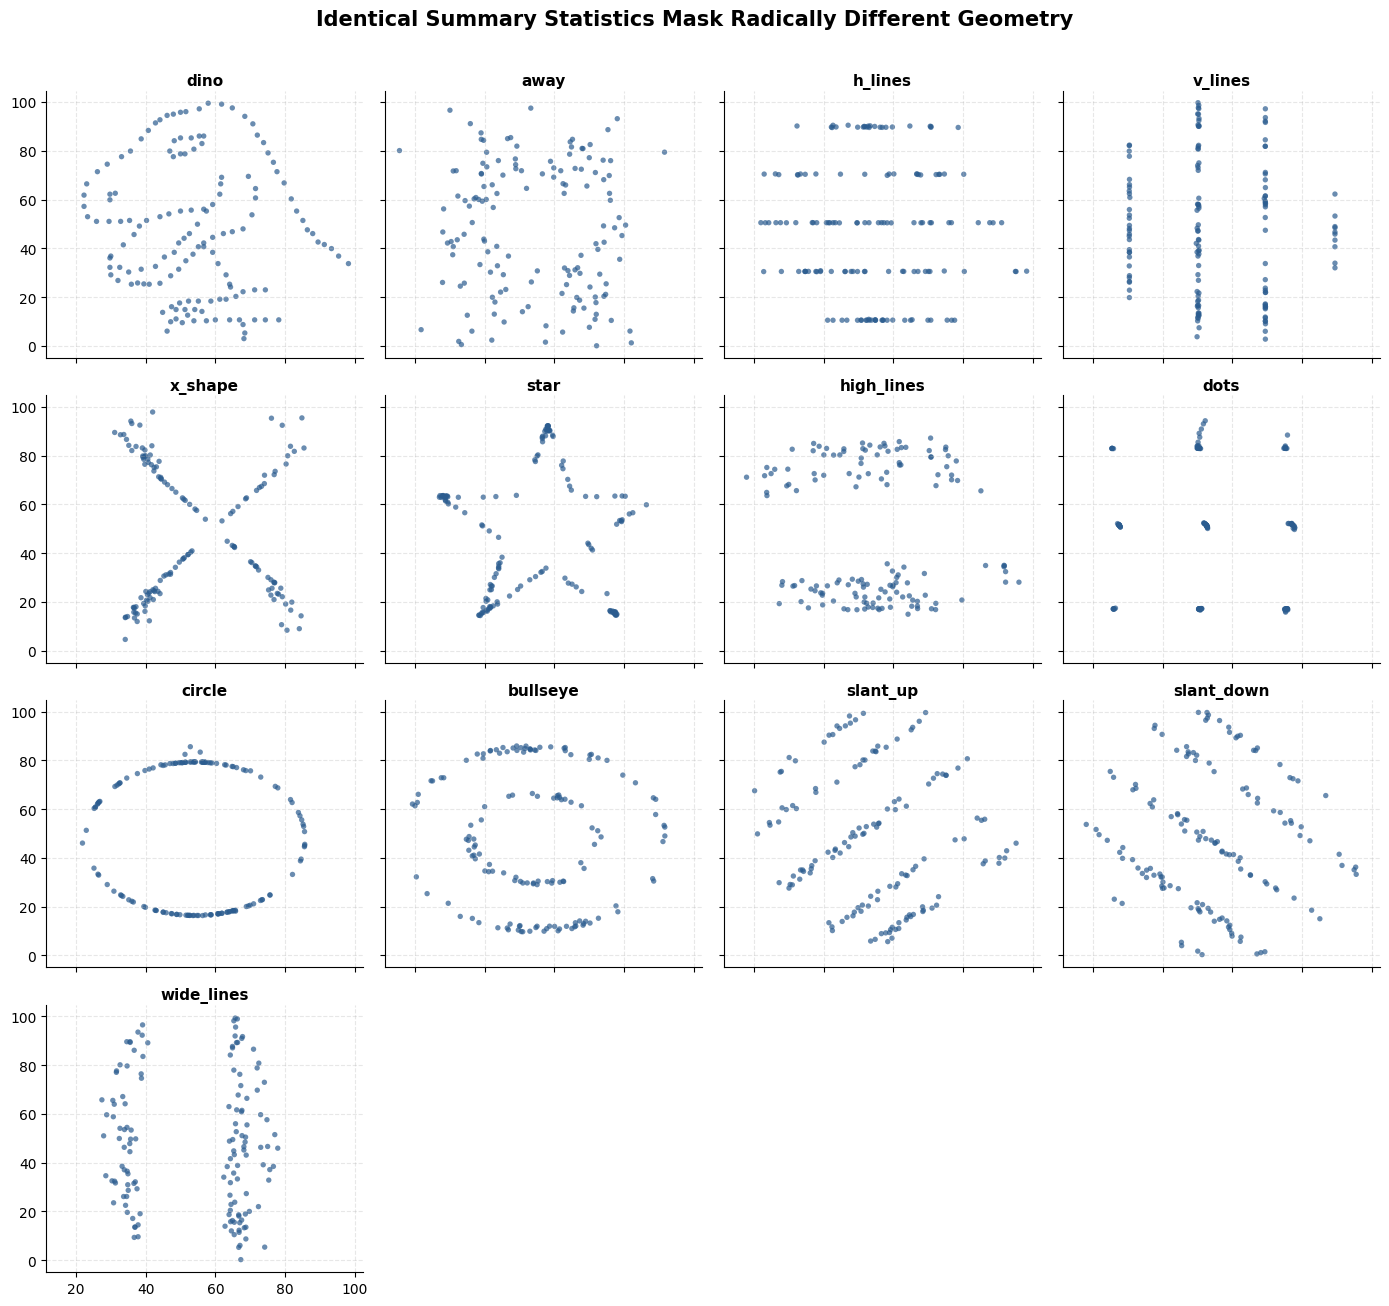

In [6]:
datasets = df['dataset'].unique()
fig, axes = plt.subplots(4, 4, figsize=(14, 14), sharex=True, sharey=True)
axes = axes.flatten()

for i, dname in enumerate(datasets):
    ax = axes[i]
    sub = df[df['dataset'] == dname]
    ax.scatter(sub['x'], sub['y'], color='#2b5c8f', alpha=0.7, s=15, edgecolors='none')
    ax.set_title(dname, fontsize=11, fontweight='bold', pad=4)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

for j in range(len(datasets), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Identical Summary Statistics Mask Radically Different Geometry", fontsize=15, fontweight='bold', y=0.93)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

### What We Actually Found
Plotting the data reveals that these 13 datasets are completely different shapes — including a dinosaur, concentric bullseyes, a star, slanted parallel lines, and an X shape.

### Question: Does having 142 points instead of 11 make summary statistics more trustworthy?
**No.** Summary statistics only measure low-order moments (central tendency, variance, and linear covariance). Larger sample sizes ($n=142$ vs $n=11$) reduce random sampling error, but they do **not** fix model misspecification. If the true structure is non-linear or geometric, a larger sample simply measures the wrong metric with higher precision.